In [1]:
import pandas as pd
import numpy as np
import math

In [2]:
# For visualisations
import matplotlib.pyplot as plt
import seaborn as sns
subplots = plt.subplots

# Setting plotting parameters for consistent graphs
plt.rcParams.update({
    'figure.figsize': (8, 4),
    'figure.dpi': 240,

    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,

    'xtick.labelsize': 10,
    'ytick.labelsize': 10,

    'axes.spines.top': False,
    'axes.spines.right': False,

    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.8,

    'axes.axisbelow': True,

    'legend.frameon': False,

    'figure.constrained_layout.use': True,
})

In [3]:
RANDOM_STATE = 42

# Credit Risk Modelling

**Dataset**: [Give Me Some Credit (Kaggle)](https://www.kaggle.com/c/GiveMeSomeCredit)

In [4]:
data_dict = pd.read_excel("../data/Data Dictionary.xls", skiprows=1)
display(data_dict)

,Variable Name,Description,Type
0,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
1,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
2,age,Age of borrower in years,integer
3,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
4,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
5,MonthlyIncome,Monthly income,real
6,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
7,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
8,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer
9,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days p...,integer


## 1. Context

### 1.1 Modelling Goals

1. How well can borrower financial and credit characteristics predict the probability of serious delinquency over a two-year horizon? 
2. What can different classification models tell us about which borrower characteristics are associated with credit risk

### 1.2 Unit of Observation

Our unit of observation is a borrower, as captured by the data at a given point in time (i.e. we have a cross-section).

### 1.3 Prediction Exercise

Estimate the **probability** that an individual borrower will experience serious financial delinquency within the next two years, using their financial and credit characteristics observed at the time of prediction.

i.e., for borrower $i$,  we have 

$Y_i = \begin{cases} 
1, & \text{if borrower experiences serious delinquency within the next 2 years} \\
0, & \text{otherwise}
\end{cases} $

And we want to estimate

$\Pr(Y_i = 1 \mid X_i)$ 

where $X_i$ represents the observed characteristics of borrower $i$.

## 2. Exploratory Data Analysis (EDA)

In [5]:
data = pd.read_csv("../data/cs-training.csv", index_col=0)

In [6]:
x_var_list = [
    # Personal attributes
    'age',
    'NumberOfDependents',
    
    # Financial attributes
    'MonthlyIncome',
    'DebtRatio',
    'RevolvingUtilizationOfUnsecuredLines',
    
    # Credit history
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

y_var = 'SeriousDlqin2yrs'

### 2.1 Structure, completeness

In [7]:
data.shape # (rows, cols)

(150000, 11)

In [8]:
data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [9]:
# Missingness check
missing = pd.DataFrame({
    'missing_count': data.isna().sum(),
    'missing_pct': data.isna().mean() * 100
}).sort_values('missing_pct', ascending=False)

display(missing)

,missing_count,missing_pct
MonthlyIncome,29731,19.820667
NumberOfDependents,3924,2.616000
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000


### 2.2 Distributions

In [10]:
# Descriptive stats of the variables in our data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


**Notes:** 
1. Many of our predictors have outliers in the right-tail. See the [boxplot diagram](#boxplot-for-x)
2. The `NumberOfTimes...` variables, all have max value as 98 - this might be a coding choice, rather than actual data? Worth investigating
3. Minimum of age is 0 - seems to be clearly wrong

#### 2.2.1 Distribution of $Y_i$

In [11]:
# Class balance check - how many defaults do we have in the data?
data['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

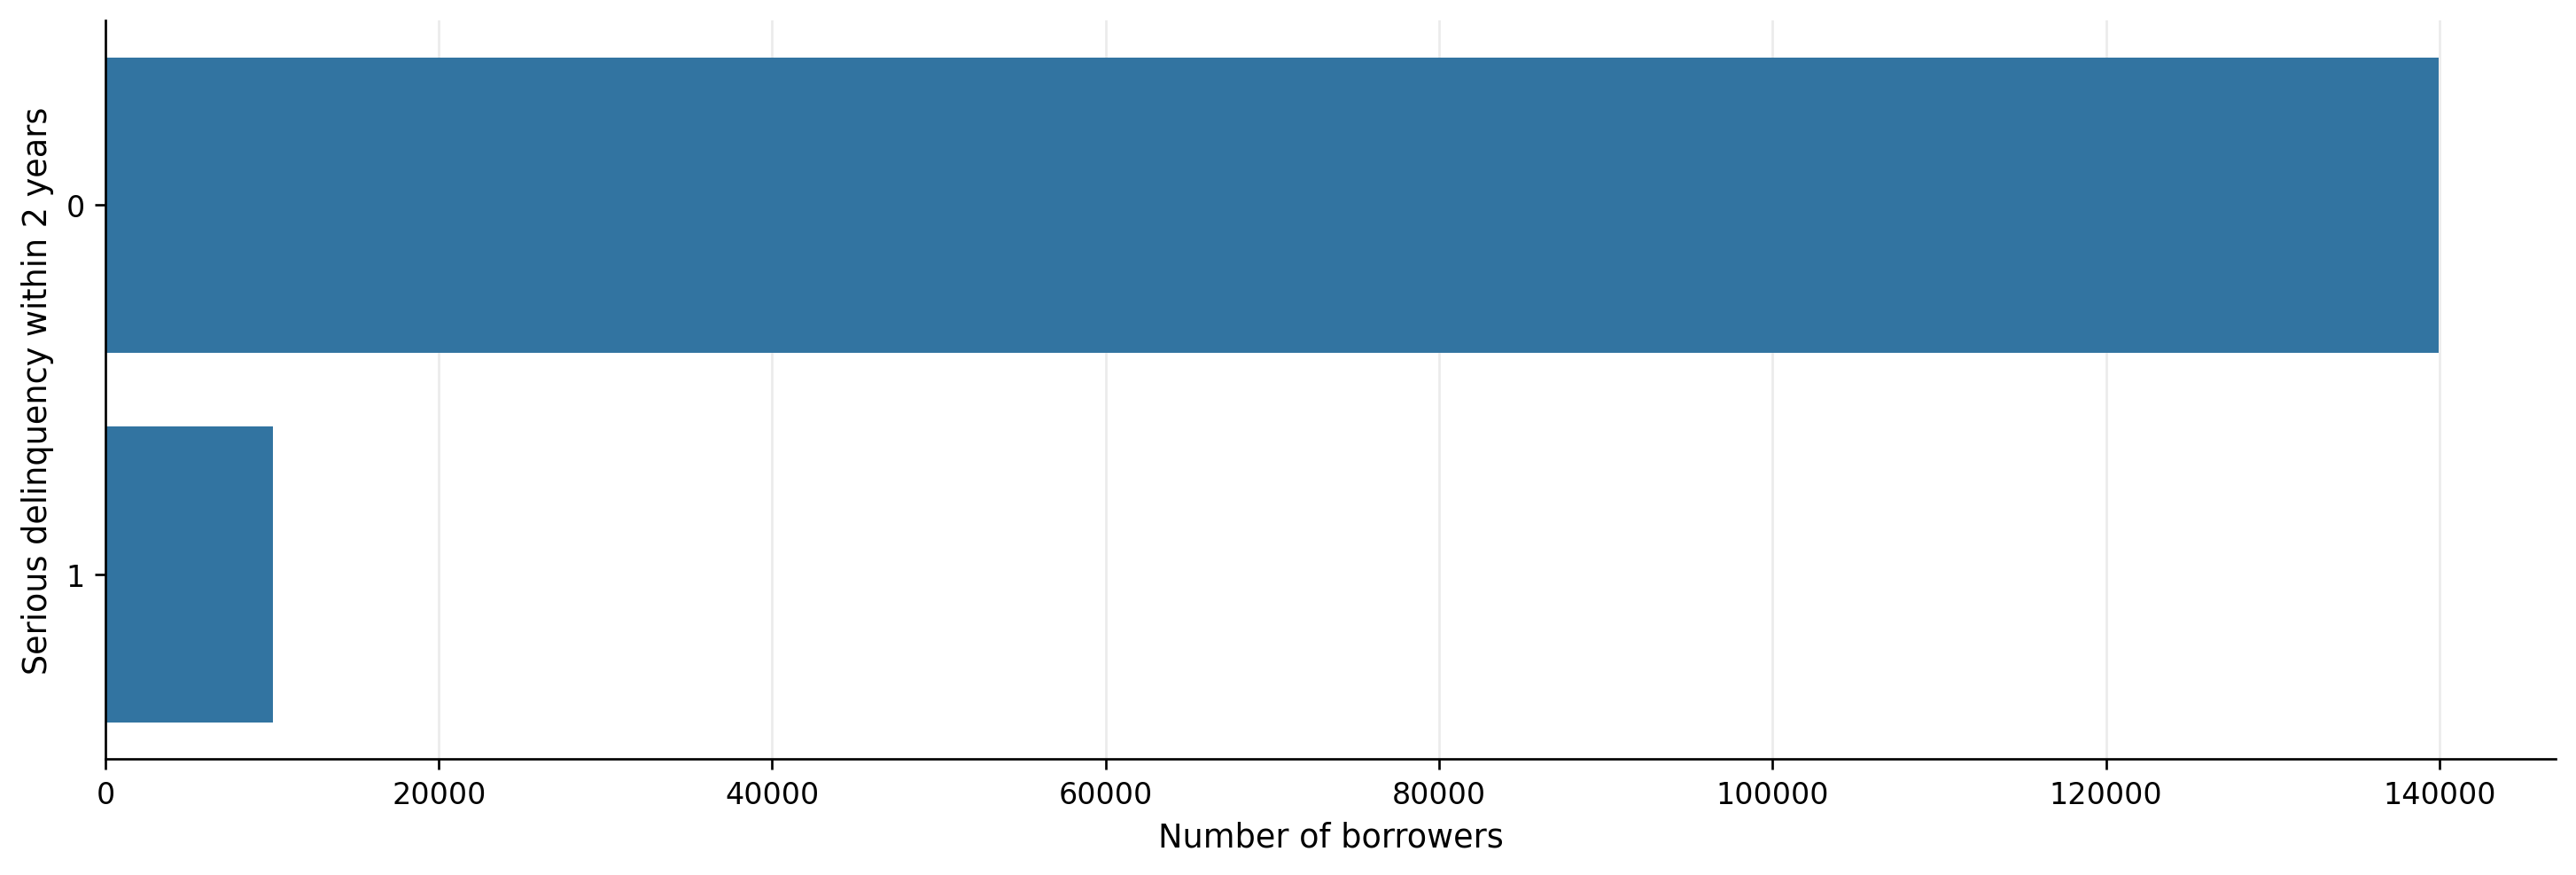

In [12]:
fig, ax = subplots(figsize=(12,4))
plot_viz_data = data['SeriousDlqin2yrs'].value_counts().sort_index()
sns.barplot(
    y=plot_viz_data.index,
    x=plot_viz_data.values,
    orient='h'
)
ax.set_ylabel('Serious delinquency within 2 years')
ax.set_xlabel('Number of borrowers')
plt.show()

**Findings**: Around 6.68% of the borrowers in this dataset ended up defaulting.

#### 2.2.2 Distribution of $X_i$'s

In [13]:
# Distributions of our predictors
display(
    data[x_var_list]
    .quantile([0, .01, .05, .10, .25, .50, .75, .90, .95, .99, 1])
    .T
)

,0.00,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99,1.00
age,0.0,24.0,29.000000,33.000000,41.000000,52.000000,63.000000,72.000000,78.0,87.000000,109.0
NumberOfDependents,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,3.0,4.000000,20.0
MonthlyIncome,0.0,0.0,1300.000000,2005.000000,3400.000000,5400.000000,8249.000000,11666.000000,14587.6,25000.000000,3008750.0
DebtRatio,0.0,0.0,0.004329,0.030874,0.175074,0.366508,0.868254,1267.000000,2449.0,4979.040000,329664.0
RevolvingUtilizationOfUnsecuredLines,0.0,0.0,0.000000,0.002969,0.029867,0.154181,0.559046,0.981278,1.0,1.092956,50708.0
NumberOfOpenCreditLinesAndLoans,0.0,0.0,2.000000,3.000000,5.000000,8.000000,11.000000,15.000000,18.0,24.000000,58.0
NumberRealEstateLoansOrLines,0.0,0.0,0.000000,0.000000,0.000000,1.000000,2.000000,2.000000,3.0,4.000000,54.0
NumberOfTime30-59DaysPastDueNotWorse,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.0,4.000000,98.0
NumberOfTime60-89DaysPastDueNotWorse,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,2.000000,98.0
NumberOfTimes90DaysLate,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,3.000000,98.0


<a id="boxplot-for-x"></a>

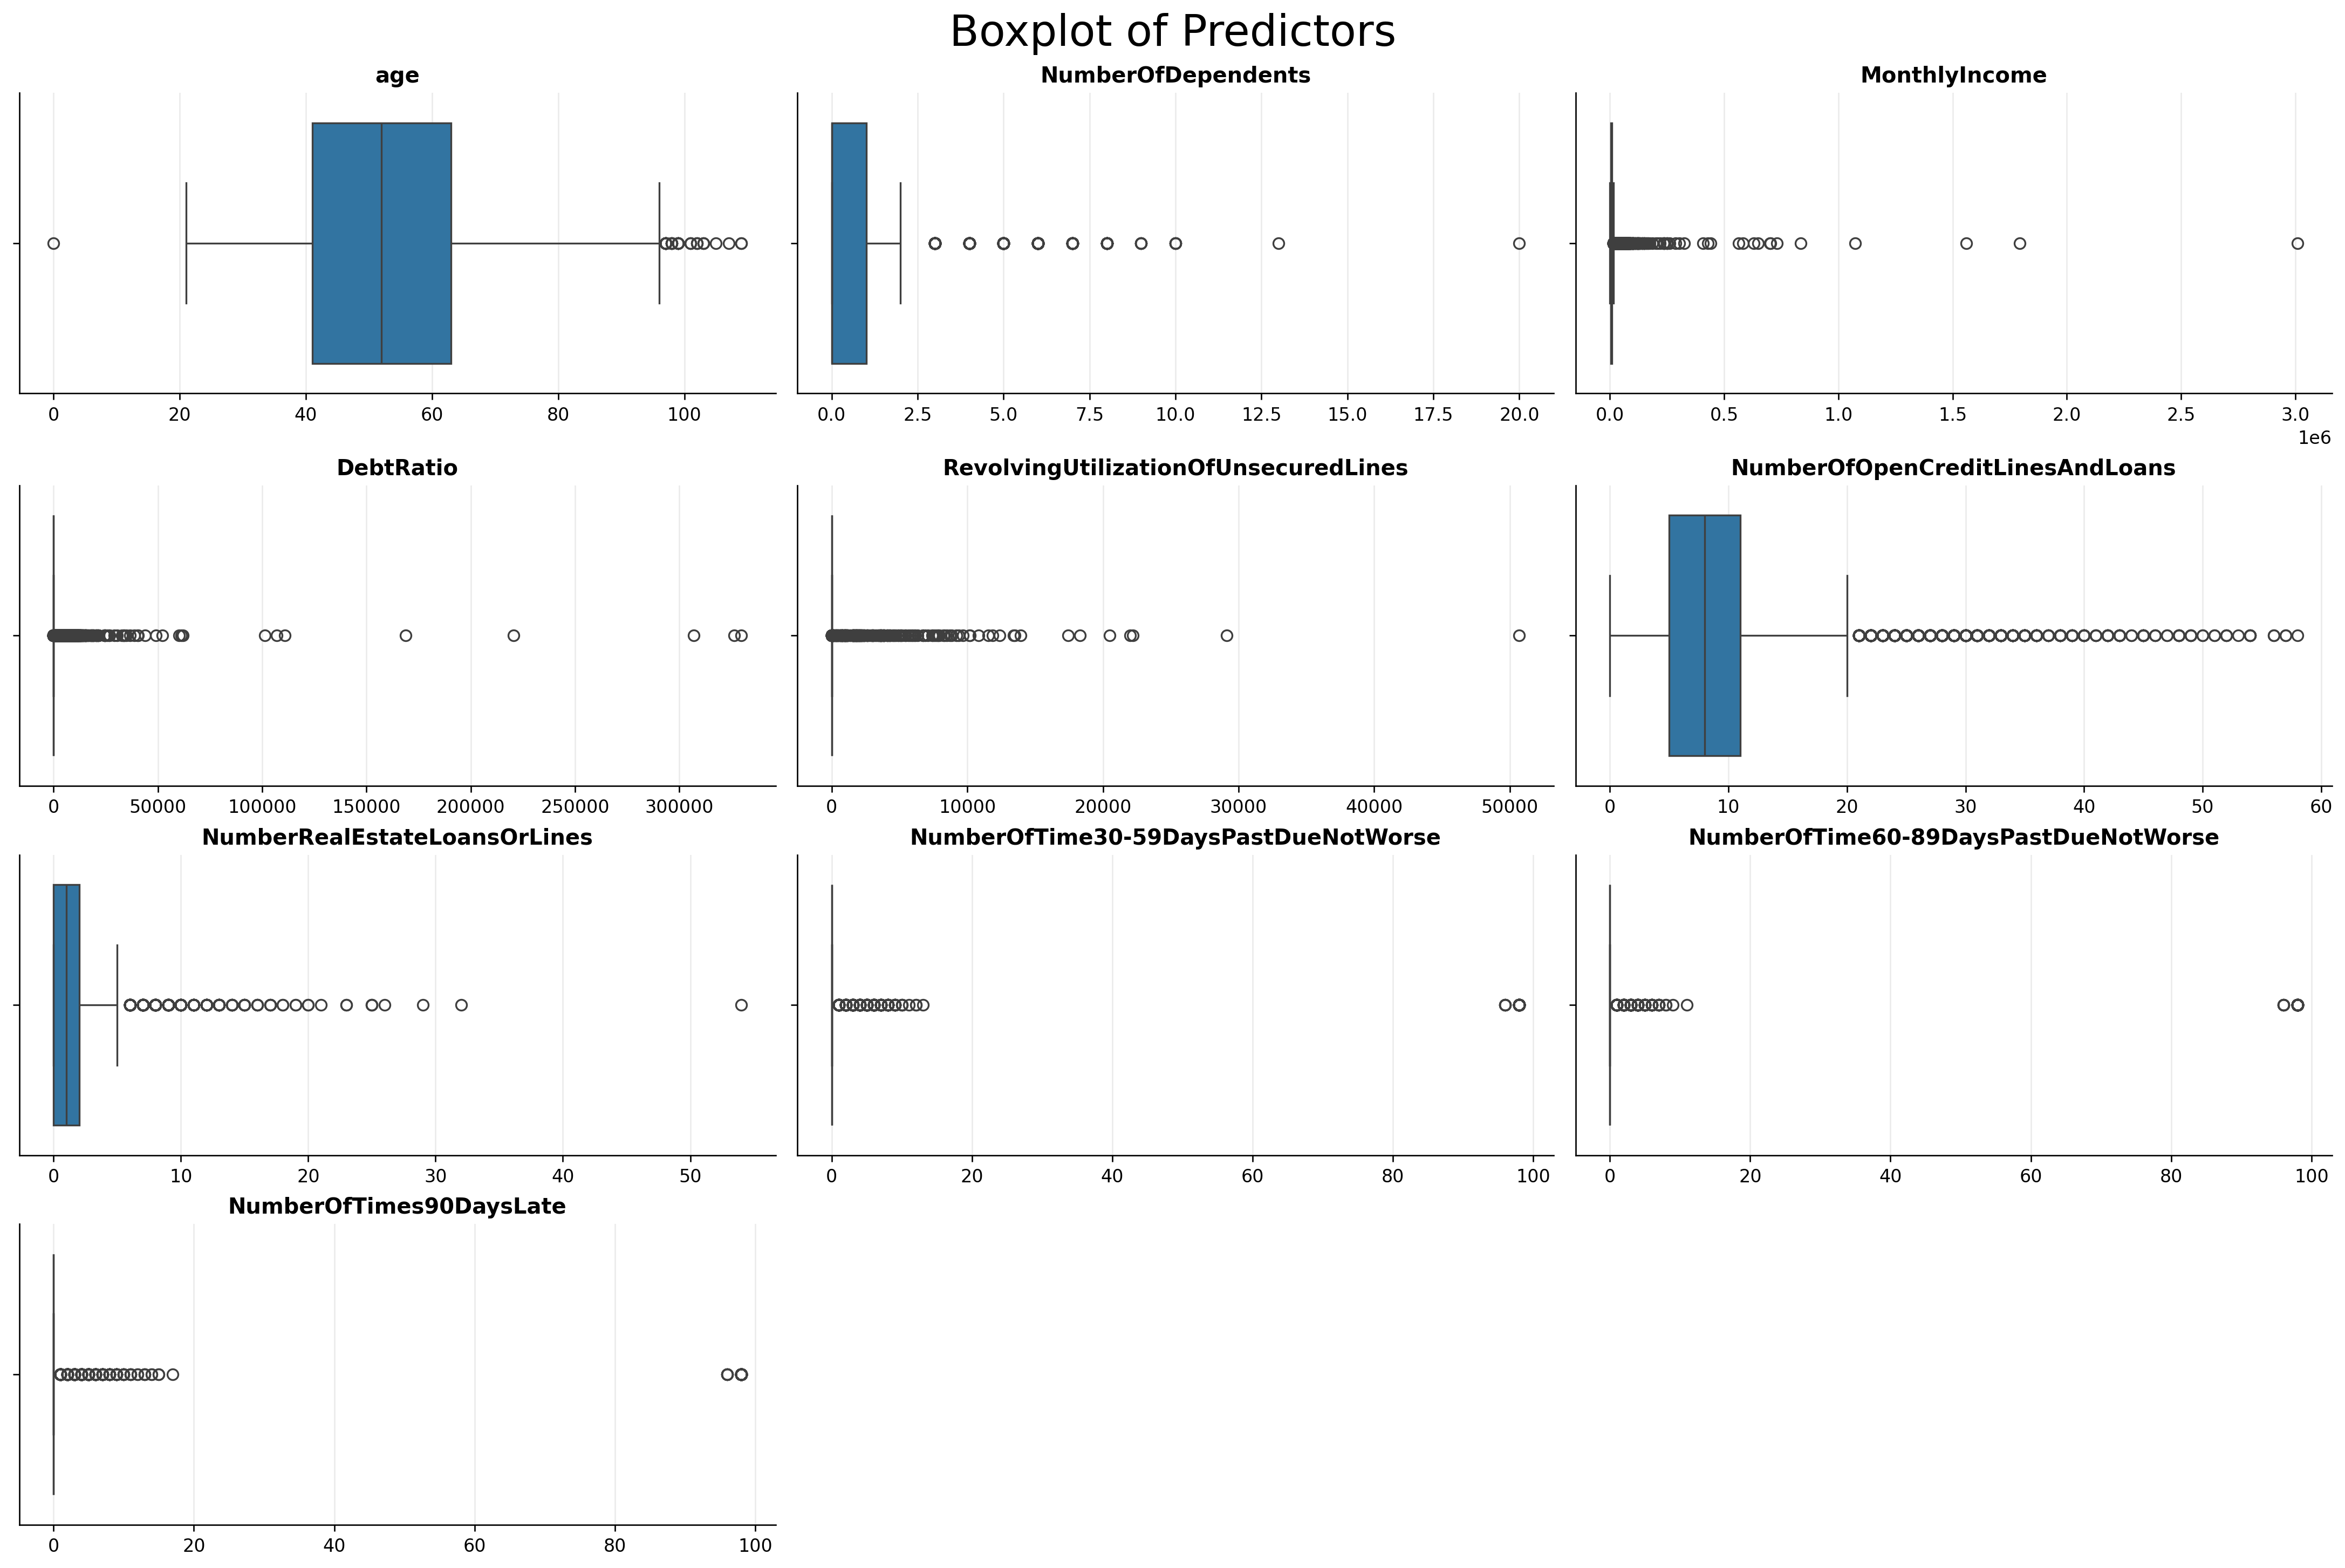

In [14]:
fig, axes = subplots(nrows=4, ncols=3, figsize=(18,12))
axes = axes.flatten()


for i,var in enumerate(x_var_list):
    sns.boxplot(x=data[var], ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    axes[i].set_xlabel("")

axes[-1].axis('off')
axes[-2].axis('off');
fig.suptitle("Boxplot of Predictors", fontsize=24);

This confirms our earlier insights
1. There is an outlier in age - one observation around 0

In [15]:
(data['age'] < 18).sum()

np.int64(1)

Since there is exactly one such obviously wrong data point, we should safely drop it in pre-processing without materially affecting the model

2. Most variables are highly right-skewed. This suggests that we should **consider a $\ln(1+x)$ transformation**

In [16]:
# Raw correlation
corr_raw = data[x_var_list + [y_var]].corr()['SeriousDlqin2yrs']

# Correlation after ln(1+x) transform
log_data = data[x_var_list].copy()
for col in x_var_list:
    log_data[col] = np.log1p(log_data[col])

corr_log = log_data.corrwith(data['SeriousDlqin2yrs'])
comparison = pd.DataFrame({
    'corr_raw': corr_raw.drop('SeriousDlqin2yrs'),
    'corr_after_log1p': corr_log
})

comparison['absolute_change'] = comparison['corr_after_log1p'].abs() - comparison['corr_raw'].abs()
comparison.sort_values('absolute_change', ascending=False)

,corr_raw,corr_after_log1p,absolute_change
NumberOfTimes90DaysLate,0.117175,0.312581,0.195406
RevolvingUtilizationOfUnsecuredLines,-0.001802,0.178767,0.176965
NumberOfTime30-59DaysPastDueNotWorse,0.125587,0.278638,0.153051
NumberOfTime60-89DaysPastDueNotWorse,0.102261,0.249055,0.146794
NumberOfOpenCreditLinesAndLoans,-0.029669,-0.062751,0.033083
NumberRealEstateLoansOrLines,-0.007038,-0.029568,0.022530
DebtRatio,-0.007602,-0.017194,0.009592
NumberOfDependents,0.046048,0.046661,0.000613
age,-0.115386,-0.114038,-0.001347
MonthlyIncome,-0.019746,-0.017929,-0.001816


Clearly, for the top 4 variables, the correlation with the log-transformed values is much higher.  
**This suggests that the relationship with the outcome may be more nearly linear after the log transformation**

3. The max value of 98 in certain variables might be a coding choice

In [17]:
late_vars = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

data.loc[
    (data[late_vars] == 98).all(axis=1),
    late_vars + [y_var]
]

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs
1734,98,98,98,1
2287,98,98,98,0
3885,98,98,98,0
4418,98,98,98,0
4706,98,98,98,0
...,...,...,...,...
147775,98,98,98,1
149154,98,98,98,1
149240,98,98,98,0
149440,98,98,98,1


The value 98 appears to be a special code rather than a genuine delinquency count. It occurs in **exactly the same 264 observations across all three delinquency variables** and is **far outside their otherwise observed distributions**. 

**We will therefore treat these values as missing for modelling purposes.**

#### 2.2.3 Conditional distribution of $X_i$'s (conditioned on $Y$)

Do the distributions of borrower characteristics differ between borrowers who did and did not subsequently experience serious delinquency?

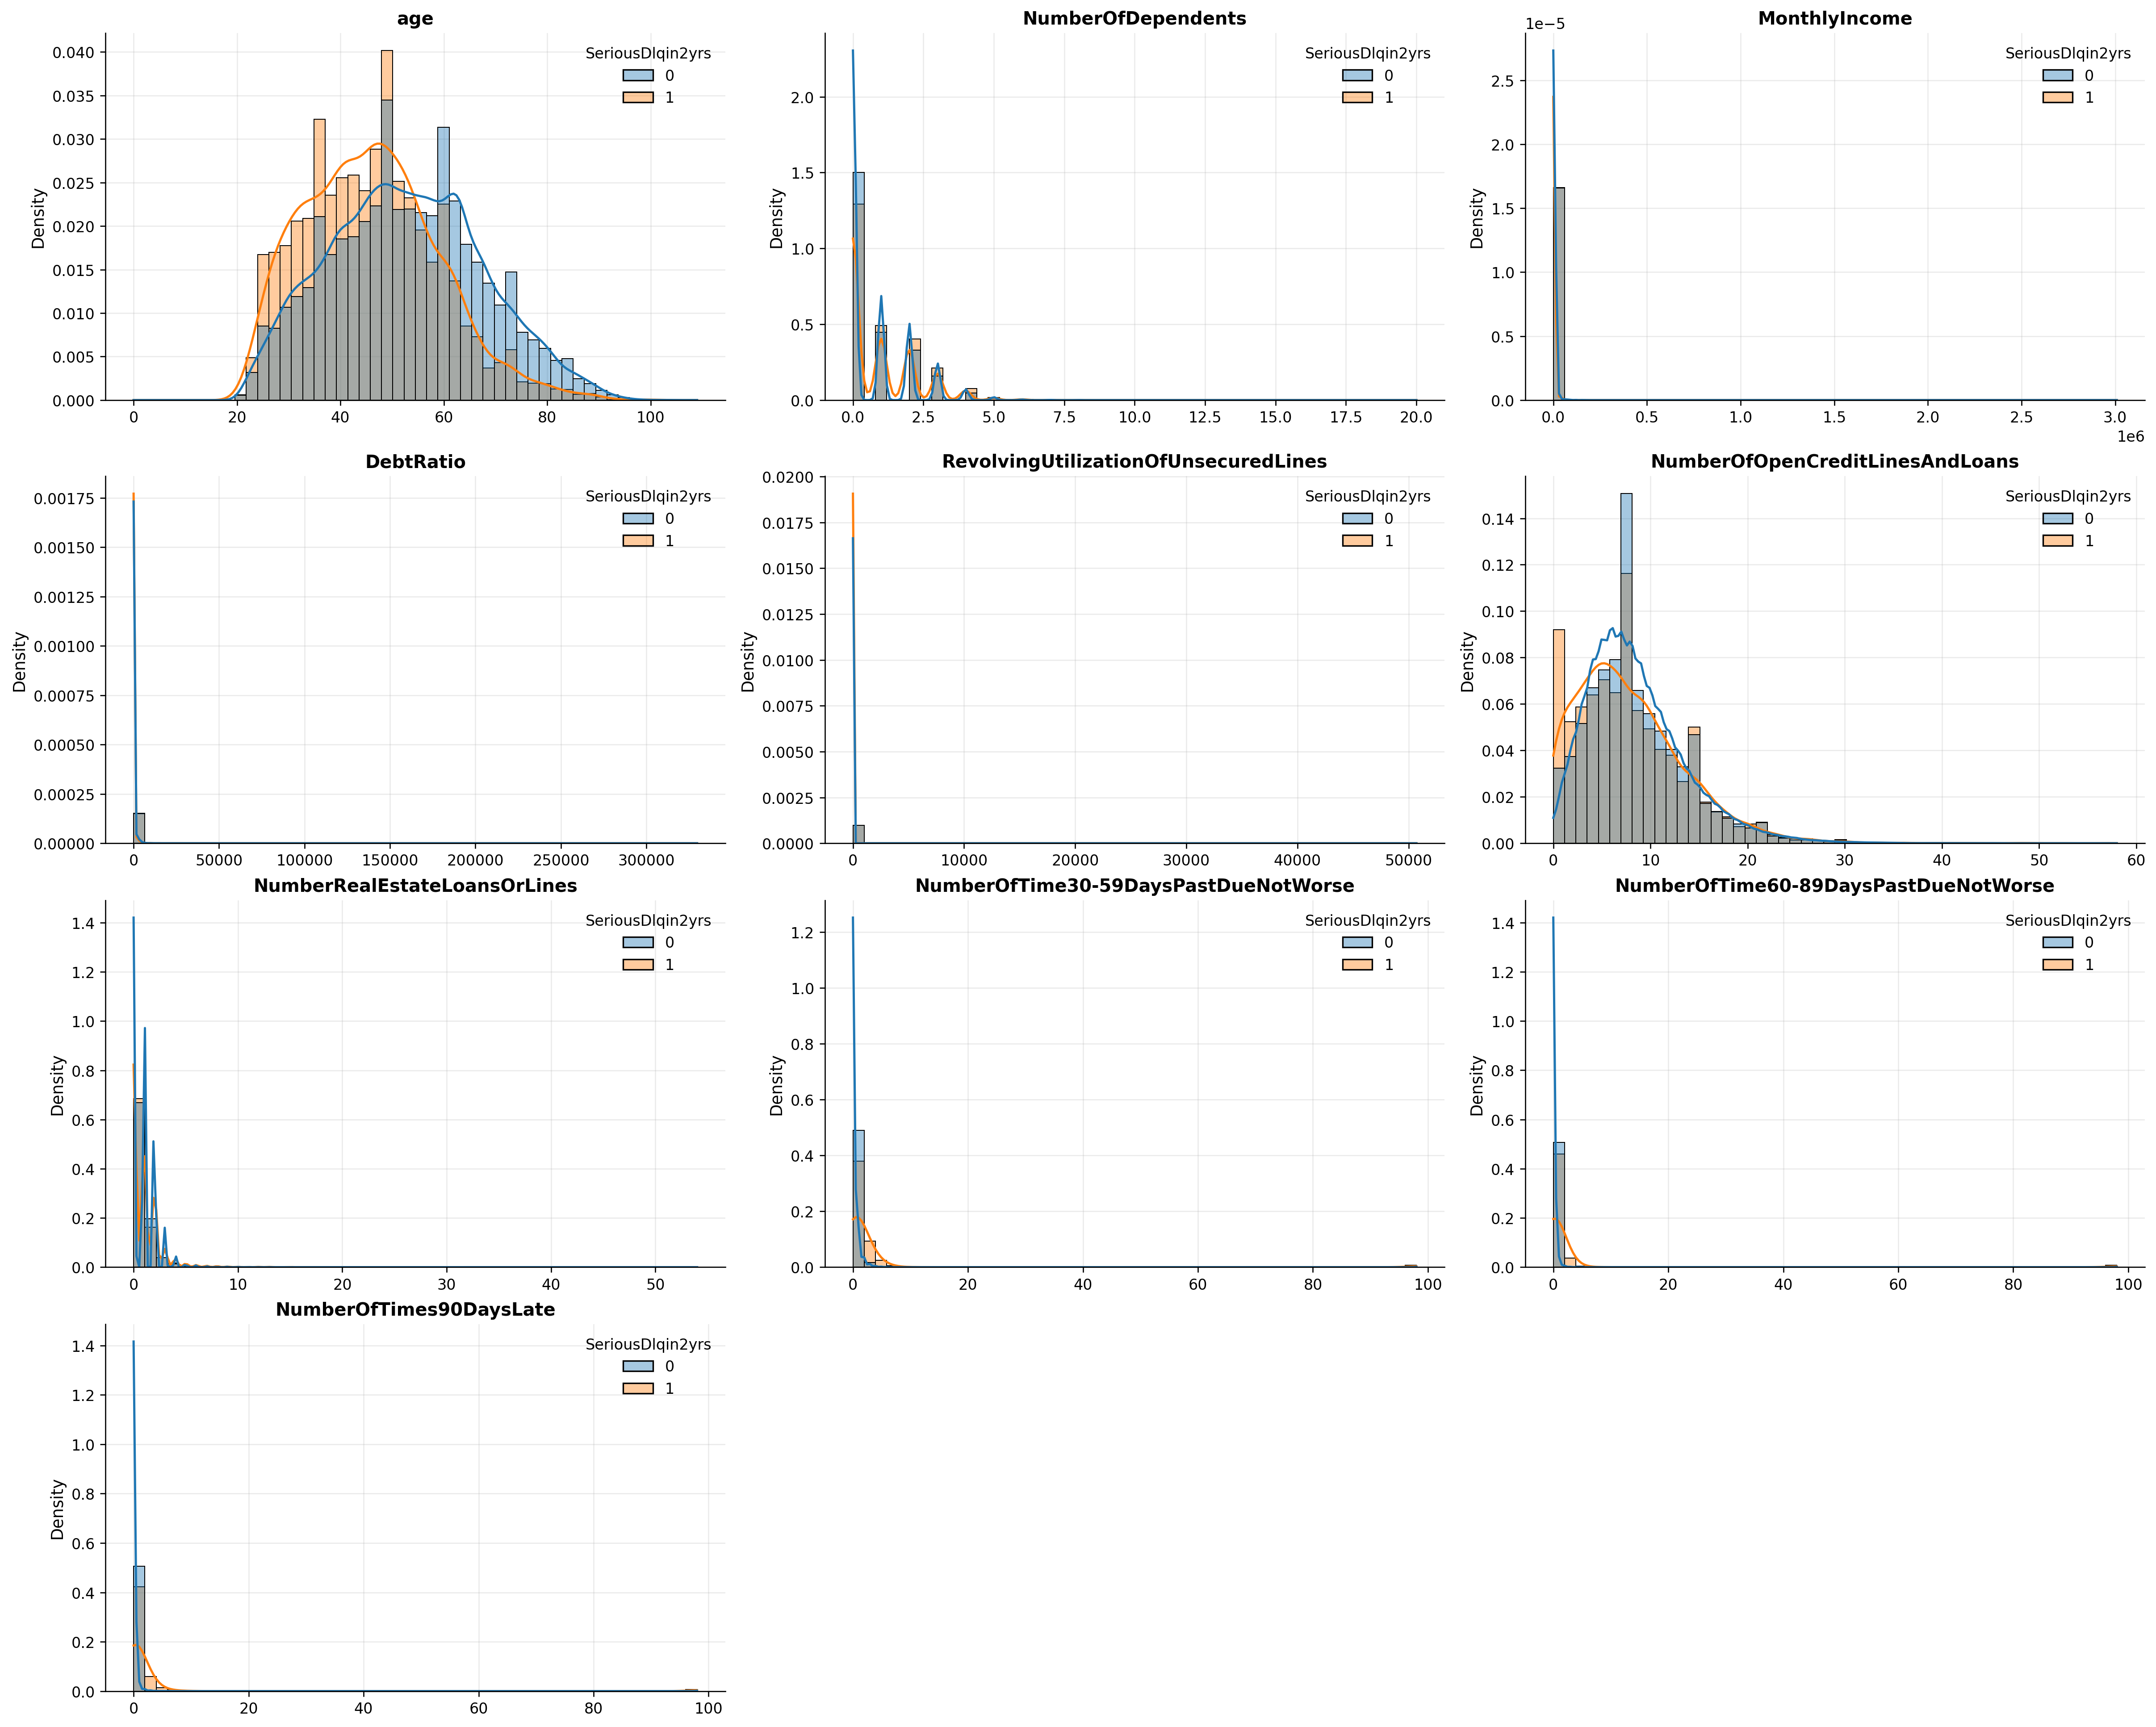

In [18]:
n_cols = 3
n_rows = math.ceil(len(x_var_list) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(x_var_list):
    sns.histplot(
        data=data,
        x=var,
        hue=y_var,
        bins=50,
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.4,
        ax=axes[i]
    )
    axes[i].set_title(var, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# Remove unused subplots
for j in range(len(x_var_list), len(axes)):
    fig.delaxes(axes[j])

plt.show();

The `NumberOf...` variables and the `RevolvingUtilization...` histograms are too compressed (due to the right-skew) and not informative right now. 

We look at the $\ln(1+x)$ transformed version of these below:

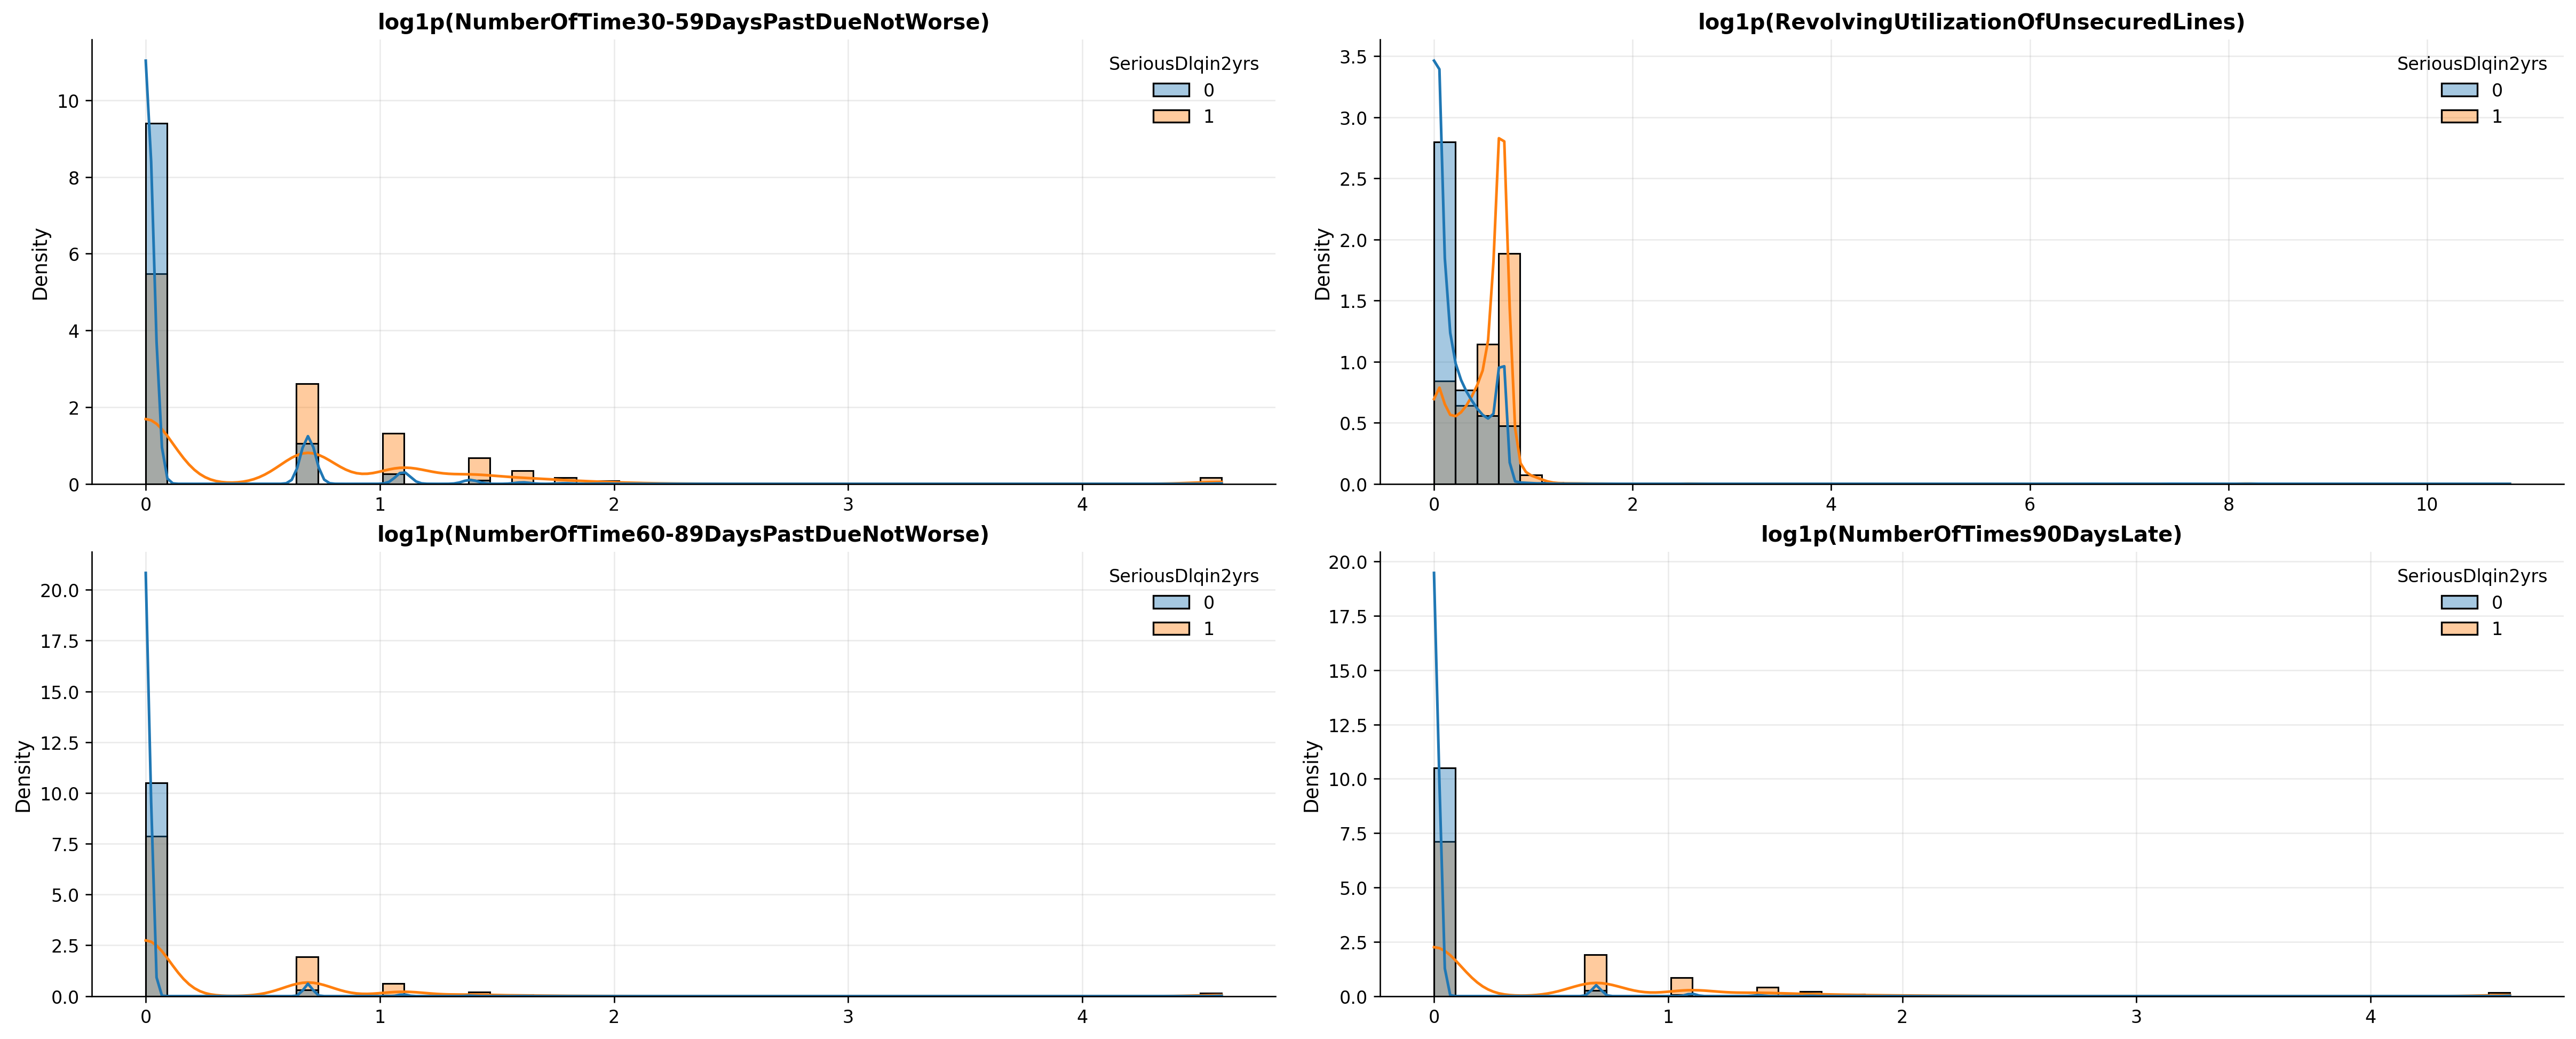

In [19]:
tmp_var_list = [    
    'NumberOfTime30-59DaysPastDueNotWorse',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

n_cols = 2
n_rows = math.ceil(len(tmp_var_list) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

tmp_data = data.copy()
for var_to_trans in tmp_var_list:
    tmp_data[var_to_trans] = np.log1p(tmp_data[var_to_trans])

for i, var in enumerate(tmp_var_list):
    sns.histplot(
        data=tmp_data,
        x=var,
        hue=y_var,
        bins=50,
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.4,
        ax=axes[i]
    )
    axes[i].set_title(f"log1p({var})", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# Remove unused subplots
for j in range(len(x_var_list), len(axes)):
    fig.delaxes(axes[j])

plt.show();

#### 2.2.4 Correlations between features ($X$'s) and outcome ($Y$)

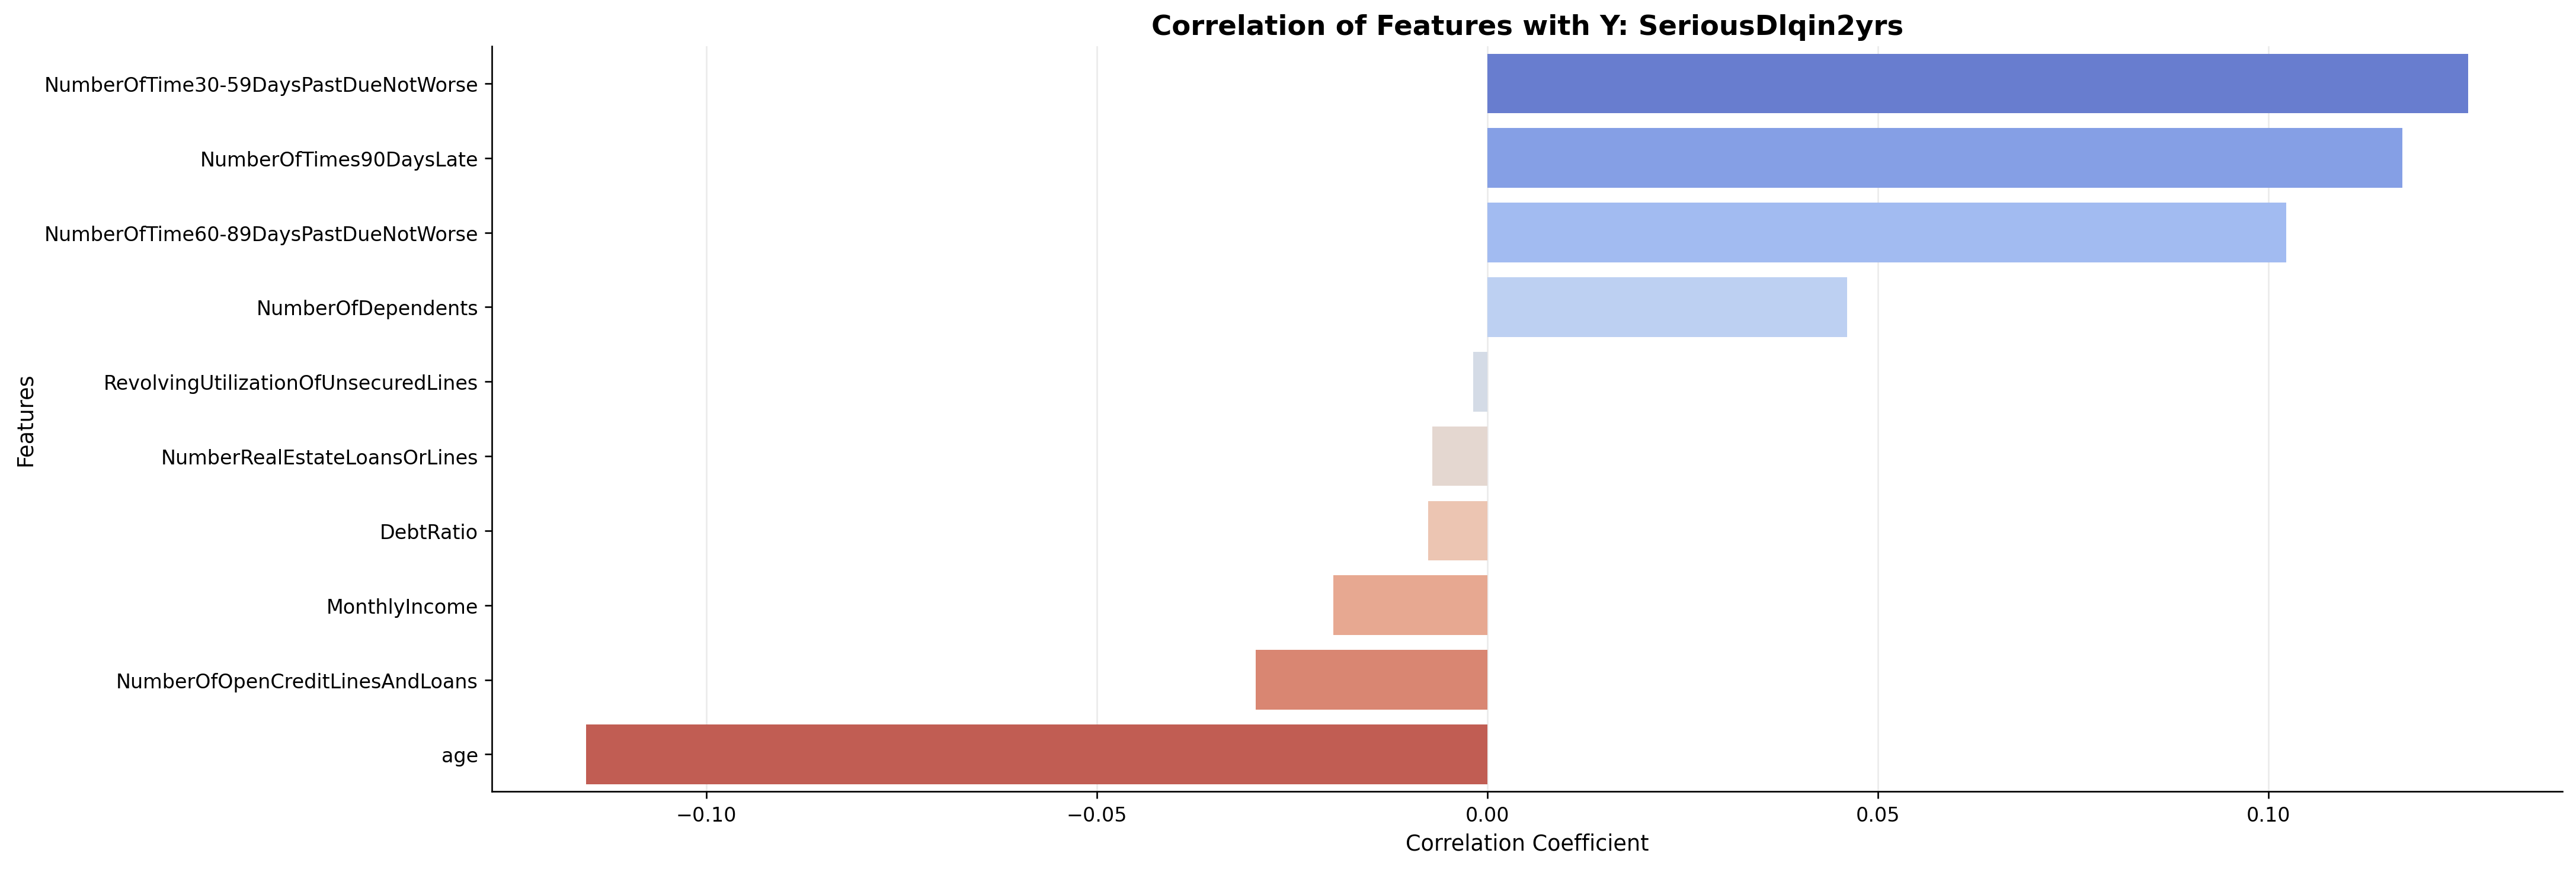

In [20]:
# Calculate correlation of each feature with the outcome variable
target_corr = data.corr()[y_var]

# Sort correlations by absolute value (for better visualization)
target_corr = target_corr.sort_values(ascending=False)
target_corr = target_corr.drop(y_var) # Drop correlation of Y with Y

plt.figure(figsize=(18, 6))
sns.barplot(
    x=target_corr.values, 
    y=target_corr.index, 
    hue=target_corr.index, 
    palette="coolwarm"
)

plt.title(f"Correlation of Features with Y: SeriousDlqin2yrs")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show();

### Pre-Processing notes after EDA

1. **Drop the row with `age`=0**  
This is an objectively invalid value.

2. **Consider $\ln(1+x)$ transformed version of the variables defined in `x_vars_fit_for_transform` below**
- The EDA showed substantially stronger linear associations with SeriousDlqin2yrs for these transformed variables.
- Treat this as a candidate specification to test in the logistic model, not an unconditional transformation rule.

3. **Treat the rows with variables in `late_vars` all equal to 98 as missing values of `late_vars`**  
The 98s appear to be a special code rather than genuine delinquency counts.

4. **Handle missing values in `MonthlyIncome` and `NumberOfDependents`.**
- MonthlyIncome: ~19.8% missing.
- NumberOfDependents: ~2.6% missing.  
We haven't decided the imputation strategy yet. That's something we'll handle as part of the modelling pipeline.

5. **Standardise predictors for logistic regression if needed.**  
We'll do this as part of the preprocessing pipeline, using only the training data.

6. **Keep the original class balance.**  
The 6.68% positive rate is a characteristic of the prediction problem. We'll use appropriate evaluation metrics and consider class weighting if justified by model performance.

In [21]:
x_vars_fit_for_transform = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

late_vars = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]